In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline
import joblib
import os

In [2]:
df=pd.read_csv(r'D:\AI_Public_Health_Project\data\kenya_public_health_vulnerability.csv')

In [3]:
df.head()

,County,Population,Population_Density,Poverty_Rate,Health_Facilities,Doctors_per_10000,Immunization_Coverage,Clean_Water_Access,Maternal_Mortality,Under5_Mortality,Malnutrition_Rate,HIV_Prevalence,Malaria_Prevalence,Unemployment_Rate,Vulnerability_Level,Vulnerability_Encoded,Vulnerability_Score,Latitude,Longitude
0,Mombasa,211911,1675,53,129,2.0,92,49,473,89,8,2.2,21,5,High,0,28.85,-4.0435,39.6682
1,Kwale,3809961,1685,44,150,9.5,52,90,160,23,35,11.6,24,19,Medium,2,32.15,-4.1816,39.4606
2,Kilifi,3310152,4987,24,294,6.8,70,46,285,35,14,5.9,40,17,Low,1,30.60,-3.5107,39.9093
3,Tana River,403085,4986,79,44,10.4,62,65,352,52,13,7.3,1,20,Very High,3,38.40,-1.6518,40.0287
4,Lamu,1061972,4935,28,159,7.1,83,91,297,78,18,12.0,29,9,Medium,2,18.70,-2.2717,40.9020


In [4]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Vulnerability_Encoded'] = encoder.fit_transform(
    df['Vulnerability_Level']
)

In [5]:
X = df.drop(
    ['County',
     'Vulnerability_Level',
     'Vulnerability_Encoded'],
    axis=1
)

y = df['Vulnerability_Encoded']

print(X.head())

   Population  Population_Density  Poverty_Rate  Health_Facilities  \
0      211911                1675            53                129   
1     3809961                1685            44                150   
2     3310152                4987            24                294   
3      403085                4986            79                 44   
4     1061972                4935            28                159   

   Doctors_per_10000  Immunization_Coverage  Clean_Water_Access  \
0                2.0                     92                  49   
1                9.5                     52                  90   
2                6.8                     70                  46   
3               10.4                     62                  65   
4                7.1                     83                  91   

   Maternal_Mortality  Under5_Mortality  Malnutrition_Rate  HIV_Prevalence  \
0                 473                89                  8             2.2   
1                 16

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(37, 16)
(10, 16)


In [7]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [8]:
predictions = rf.predict(X_test)

In [9]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print(
    "Accuracy:",
    accuracy_score(y_test, predictions)
)

print(
    classification_report(
        y_test,
        predictions
    )
)

Accuracy: 0.8


D:\AI_Public_Health_Project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\AI_Public_Health_Project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.00      0.00      0.00         1
           2       0.60      1.00      0.75         3
           3       1.00      1.00      1.00         4

    accuracy                           0.80        10
   macro avg       0.65      0.62      0.60        10
weighted avg       0.78      0.80      0.76        10



D:\AI_Public_Health_Project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


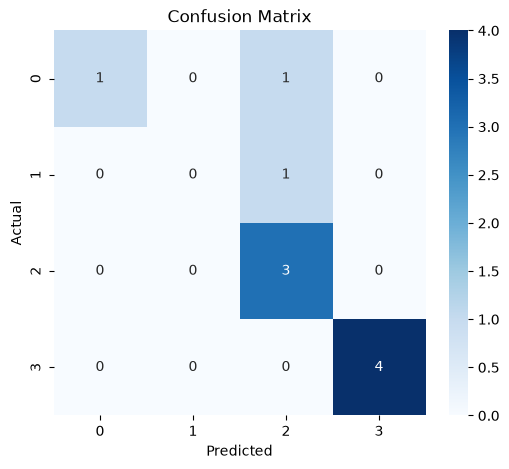

In [10]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(
        y_test,
        predictions
    ),
    annot=True,
    cmap='Blues',
    fmt='d'
)

plt.title('Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [11]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

importance

,Feature,Importance
2,Poverty_Rate,0.299343
13,Vulnerability_Score,0.108340
15,Longitude,0.087606
10,HIV_Prevalence,0.064208
14,Latitude,0.051633
0,Population,0.047834
4,Doctors_per_10000,0.047723
3,Health_Facilities,0.038007
7,Maternal_Mortality,0.037415
9,Malnutrition_Rate,0.037086


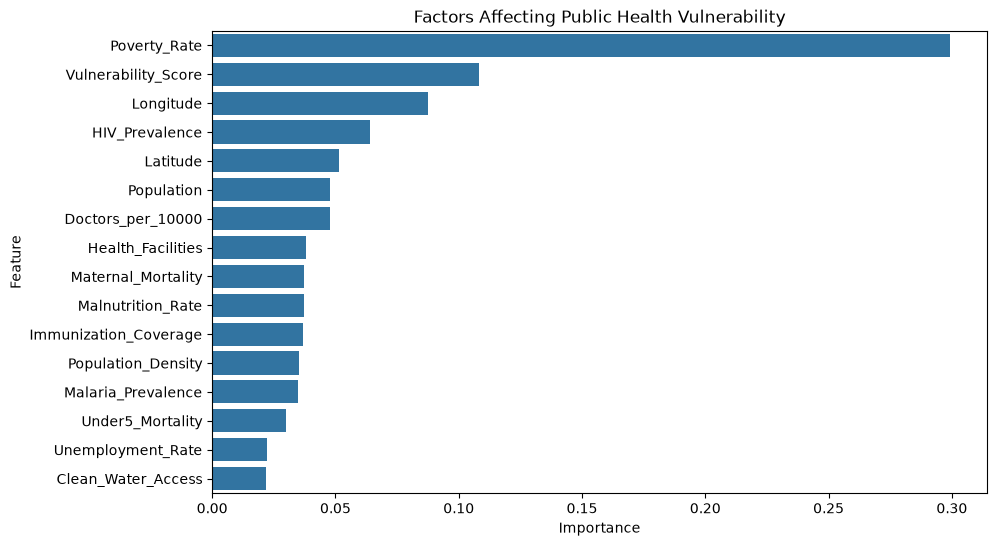

In [12]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title(
    'Factors Affecting Public Health Vulnerability'
)

plt.show()

In [13]:
import joblib

joblib.dump(
    rf,
    '../models/vulnerability_model.pkl'
)

joblib.dump(
    encoder,
    '../models/label_encoder.pkl'
)

['../models/label_encoder.pkl']

In [14]:
df['Vulnerability_Score'] = (
      df['Poverty_Rate']*0.25
    + (100-df['Immunization_Coverage'])*0.20
    + (100-df['Clean_Water_Access'])*0.20
    + df['Malnutrition_Rate']*0.15
    + df['Malaria_Prevalence']*0.10
    + df['Unemployment_Rate']*0.10
)

In [15]:
df[
    ['County',
     'Vulnerability_Score']
].head()

,County,Vulnerability_Score
0,Mombasa,28.85
1,Kwale,32.15
2,Kilifi,30.60
3,Tana River,38.40
4,Lamu,18.70


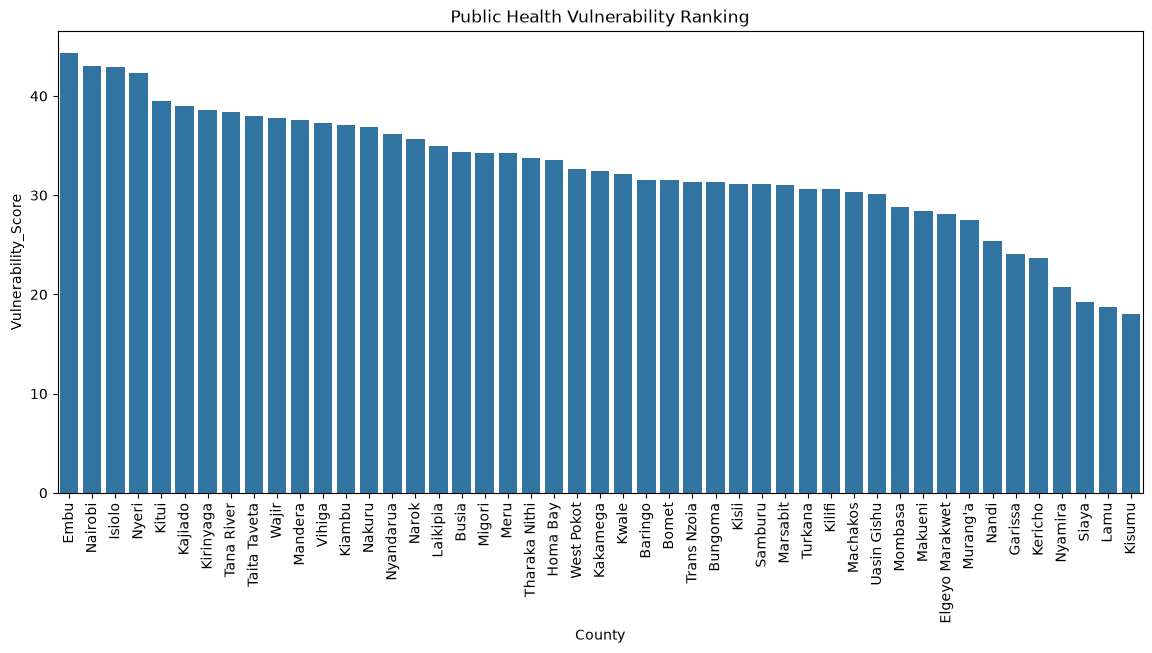

In [16]:
top = df.sort_values(
    'Vulnerability_Score',
    ascending=False
)

plt.figure(figsize=(14,6))

sns.barplot(
    data=top,
    x='County',
    y='Vulnerability_Score'
)

plt.xticks(rotation=90)

plt.title(
    'Public Health Vulnerability Ranking'
)

plt.show()

In [17]:
df.to_csv(
    r'D:\AI_Public_Health_Project\data\kenya_public_health_vulnerability.csv',
    index=False
)

In [18]:
rf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [19]:
import os
os.getcwd()

'D:\\AI_Public_Health_Project\\notebooks'

In [20]:
import joblib

joblib.dump(
    rf,
    r'D:\AI_Public_Health_Project\models\vulnerability_model.pkl'
)

joblib.dump(
    encoder,
    r'D:\AI_Public_Health_Project\models\label_encoder.pkl'
)

['D:\\AI_Public_Health_Project\\models\\label_encoder.pkl']

In [21]:
import os
os.getcwd()

'D:\\AI_Public_Health_Project\\notebooks'

In [22]:
!pip install seaborn


In [23]:
import sklearn
print(sklearn.__version__)

1.9.0
